In [2]:

# Import Libraries


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# Machine Learning Tools


from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# Linear Models


from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)


# Tree-Based Models


from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor


# Visualization


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:

# Summary
# In this step, I loaded the preprocessed training and test
# datasets. Then, I applied log transformation to the target
# variable because the competition uses RMSLE as the
# evaluation metric.



# Load Preprocessed Datasets

X = pd.read_csv("../Outputs/pipeline1_train_preprocessed.csv")

y_raw = pd.read_csv(
    "../Outputs/pipeline1_train_target.csv"
)["SalePrice"]

X_kaggle = pd.read_csv(
    "../Outputs/pipeline1_test_preprocessed.csv"
)

print("Datasets loaded successfully!\n")

print(f"Training Features : {X.shape}")
print(f"Target Shape      : {y_raw.shape}")
print(f"Test Features     : {X_kaggle.shape}")


# Log Transform Target


y = np.log1p(y_raw)

print("\nTarget log transformation completed successfully!\n")

print("Original Target Statistics:")
display(y_raw.describe())

print("\nLog-Transformed Target Statistics:")
display(y.describe())

Datasets loaded successfully!

Training Features : (1460, 208)
Target Shape      : (1460,)
Test Features     : (1459, 208)

Target log transformation completed successfully!

Original Target Statistics:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


Log-Transformed Target Statistics:


count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64

In [4]:

# Train / Test Split


X_train, X_test_split, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train/Test Split completed!\n")

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test_split.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

Train/Test Split completed!

X_train : (1168, 208)
X_test  : (292, 208)
y_train : (1168,)
y_test  : (292,)


In [5]:

# Summary
# StandardScaler is applied only for linear models
# (Linear Regression, Ridge, Lasso, ElasticNet).
# Tree-based models such as Random Forest, XGBoost,
# and LightGBM do not require feature scaling.


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_split),
    columns=X_test_split.columns,
    index=X_test_split.index
)

print("Feature Scaling completed successfully!\n")

print(f"Scaled Train Shape : {X_train_scaled.shape}")
print(f"Scaled Test Shape  : {X_test_scaled.shape}")

Feature Scaling completed successfully!

Scaled Train Shape : (1168, 208)
Scaled Test Shape  : (292, 208)


In [6]:
print(pd.read_csv("../Outputs/pipeline1_train_preprocessed.csv").shape)

print(
    pd.read_csv("../Outputs/pipeline1_train_preprocessed.csv")
    .select_dtypes(include="object")
    .columns.tolist()
)

(1460, 208)
[]


In [7]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)


# Summary
# In this step, I created a 5-Fold Cross-Validation
# framework to evaluate machine learning models.
# Cross-validation provides a more reliable estimate
# of model performance than a single train/test split.



# Create K-Fold Cross Validation


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation created successfully!")

5-Fold Cross-Validation created successfully!


In [8]:

# Cross-Validation Evaluation Function


def rmse_cv(model, X, y):

    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=kf
    )

    return -scores

In [9]:

# Store Model Results


results = {}

print("Results dictionary created successfully!")

print("\nReady to evaluate models using Cross-Validation.")

Results dictionary created successfully!

Ready to evaluate models using Cross-Validation.


In [10]:
print(f"Number of folds : {kf.get_n_splits()}")

Number of folds : 5


In [11]:
print(type(X_train))
print(type(y_train))

print(X_train.shape)
print(y_train.shape)

<class 'pandas.DataFrame'>
<class 'pandas.Series'>
(1168, 208)
(1168,)


In [12]:

# Prepare Data for XGBoost

print("="*50)
print("Missing Value Check")
print("="*50)

print("Before fillna")
print(f"Train : {X_train.isnull().sum().sum()}")
print(f"Test  : {X_test_split.isnull().sum().sum()}")
print(f"Kaggle: {X_kaggle.isnull().sum().sum()}")

X_train_xgb = X_train.fillna(0)
X_test_xgb = X_test_split.fillna(0)
X_kaggle_xgb = X_kaggle.fillna(0)

print("\nAfter fillna")
print(f"Train : {X_train_xgb.isnull().sum().sum()}")
print(f"Test  : {X_test_xgb.isnull().sum().sum()}")
print(f"Kaggle: {X_kaggle_xgb.isnull().sum().sum()}")

print("Missing values filled successfully!")

print(f"Train Missing : {X_train_xgb.isnull().sum().sum()}")
print(f"Test Missing  : {X_test_xgb.isnull().sum().sum()}")
print(f"Kaggle Missing: {X_kaggle_xgb.isnull().sum().sum()}")






Missing Value Check
Before fillna
Train : 1166
Test  : 302
Kaggle: 1520

After fillna
Train : 0
Test  : 0
Kaggle: 0
Missing values filled successfully!
Train Missing : 0
Test Missing  : 0
Kaggle Missing: 0


In [13]:

# Summary
# In this step, I trained the tuned XGBoost model
# obtained from Hyperparameter Tuning using
# 5-Fold Cross Validation. Then, I retrained the
# best model on the full training dataset and
# generated predictions for the Kaggle test dataset.



# Train XGBoost Model


# xgb = XGBRegressor(

#     objective="reg:squarederror",

#     n_estimators=3000,

#     learning_rate=0.05,

#     max_depth=4,

#     subsample=0.7,

#     colsample_bytree=0.7,

#     reg_alpha=0.1,

#     reg_lambda=1.0,

#     random_state=42,

#     n_jobs=-1,

#     verbosity=0
# )

#After hyperparameter tuning, the best XGBoost model is defined as follows:

best_xgb = XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=1000,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# 5-Fold Cross Validation


scores = rmse_cv(
    best_xgb,
    X_train_xgb,
    y_train
)

results["XGBoost"] = scores

print("=" * 50)
print("Cross Validation Results")
print("=" * 50)

print(f"Mean RMSE : {scores.mean():.5f}")
print(f"Std RMSE  : {scores.std():.5f}")


# Train Final Model


best_xgb.fit(
    X_train_xgb,
    y_train
)

print("\nFinal XGBoost model trained successfully!")


# Validation Prediction


val_pred_log = best_xgb.predict(X_test_xgb)

val_pred = np.expm1(val_pred_log)

print("\nValidation prediction completed!")

print(f"Prediction Shape : {val_pred.shape}")


# Kaggle Prediction
# 
# Retrain on Full Training Dataset


X_full = X.fillna(0)
y_full = y




best_xgb.fit(
    X_full,
    y_full
)

print("\nModel retrained on the full training dataset!")


# Kaggle Prediction


kaggle_pred_log = best_xgb.predict(X_kaggle_xgb)

kaggle_pred = np.expm1(kaggle_pred_log)
    
print("\nKaggle prediction completed!")

print(f"Kaggle Prediction Shape : {kaggle_pred.shape}")

Cross Validation Results
Mean RMSE : 0.12071
Std RMSE  : 0.01628

Final XGBoost model trained successfully!

Validation prediction completed!
Prediction Shape : (292,)

Model retrained on the full training dataset!

Kaggle prediction completed!
Kaggle Prediction Shape : (1459,)


In [14]:

# Summary
# In this step, I created the final Kaggle submission file.
# First, I converted predictions back to the original
# SalePrice scale using np.expm1(). Then, I combined the
# predictions with the test Id column and exported the
# submission as a CSV file.



# Load Original Test IDs


test_original = pd.read_csv("../Data/test.csv")


# Create Submission DataFrame


submission = pd.DataFrame({

    "Id": test_original["Id"],

    "SalePrice": kaggle_pred

})


# Save Submission File


submission.to_csv(

    "../Outputs/submission_pipeline1_v1.csv",

    index=False

)


# Verify Submission


print("=" * 50)
print("Kaggle Submission Created Successfully!")
print("=" * 50)

print(f"Submission Shape : {submission.shape}")

print("\nFirst 5 Rows:")
display(submission.head())

print("\nFile Name:")
print("submission_pipeline1_v1.csv")

Kaggle Submission Created Successfully!
Submission Shape : (1459, 2)

First 5 Rows:


,Id,SalePrice
0,1461,119845.593750
1,1462,158750.718750
2,1463,184113.812500
3,1464,199770.468750
4,1465,181964.484375



File Name:
submission_pipeline1_v1.csv


In [15]:
print(submission.shape)

print(submission.columns.tolist())

print(submission.isnull().sum())

print(submission["SalePrice"].describe())

(1459, 2)
['Id', 'SalePrice']
Id           0
SalePrice    0
dtype: int64
count      1459.000000
mean     178416.203125
std       76146.539062
min       44599.296875
25%      127960.894531
50%      157829.265625
75%      209042.984375
max      536205.750000
Name: SalePrice, dtype: float64


In [16]:
submission.head()

submission.tail()

,Id,SalePrice
1454,2915,82937.468750
1455,2916,83135.921875
1456,2917,171225.437500
1457,2918,118566.429688
1458,2919,207567.656250


In [17]:
check = pd.read_csv("../Outputs/submission_pipeline1_v1.csv")

display(check.head())

print(check.shape)

,Id,SalePrice
0,1461,119845.59
1,1462,158750.72
2,1463,184113.81
3,1464,199770.47
4,1465,181964.48


(1459, 2)


Regularized Linear Models — Ridge, Lasso, ElasticNet


In [18]:
# Baseline — Linear Regression

lr = LinearRegression()

scores = rmse_cv(
    lr,
    X_train_scaled.fillna(0),
    y_train
)

results["LinearRegression"] = scores

print("=" * 50)
print("Linear Regression")
print("=" * 50)

print(f"Mean RMSE : {scores.mean():.5f}")
print(f"Std RMSE  : {scores.std():.5f}")

Linear Regression
Mean RMSE : 0.14164
Std RMSE  : 0.01616


In [19]:
# Step 5.2: Ridge Regression

alphas = [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]

best_alpha = None
best_score = np.inf

print("=" * 50)
print("Ridge Regression")
print("=" * 50)

for alpha in alphas:

    ridge = Ridge(alpha=alpha)

    scores = rmse_cv(
        ridge,
        X_train_scaled.fillna(0),
        y_train
    )

    mean_rmse = scores.mean()

    print(
        f"alpha={alpha:>6} | "
        f"RMSE={mean_rmse:.5f} "
        f"(+/- {scores.std():.5f})"
    )

    if mean_rmse < best_score:
        best_score = mean_rmse
        best_alpha = alpha


print("\nBest Alpha:", best_alpha)

best_ridge = Ridge(alpha=best_alpha)

scores = rmse_cv(
    best_ridge,
    X_train_scaled.fillna(0),
    y_train
)

results["Ridge"] = scores

print("\nFinal Ridge Performance")

print(f"Mean RMSE : {scores.mean():.5f}")
print(f"Std RMSE  : {scores.std():.5f}")

Ridge Regression
alpha=   0.1 | RMSE=0.14142 (+/- 0.01642)
alpha=   1.0 | RMSE=0.14038 (+/- 0.01753)
alpha=   5.0 | RMSE=0.13856 (+/- 0.01907)
alpha=  10.0 | RMSE=0.13784 (+/- 0.01987)
alpha=  50.0 | RMSE=0.13683 (+/- 0.02173)
alpha= 100.0 | RMSE=0.13613 (+/- 0.02233)

Best Alpha: 100.0

Final Ridge Performance
Mean RMSE : 0.13613
Std RMSE  : 0.02233


In [20]:
# Lasso Regression

alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]

best_alpha = None
best_score = np.inf

print("Lasso Regression\n")

for alpha in alphas:

    lasso = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    scores = rmse_cv(
        lasso,
        X_train_scaled.fillna(0),
        y_train
    )

    mean_rmse = scores.mean()

    print(
        f"alpha={alpha:<7} "
        f"RMSE={mean_rmse:.5f} "
        f"(+/- {scores.std():.5f})"
    )

    if mean_rmse < best_score:
        best_score = mean_rmse
        best_alpha = alpha


print(f"\nBest Alpha : {best_alpha}")

best_lasso = Lasso(
    alpha=best_alpha,
    max_iter=10000
)

scores = rmse_cv(
    best_lasso,
    X_train_scaled.fillna(0),
    y_train
)

results["Lasso"] = scores

print(f"\nMean RMSE : {scores.mean():.5f}")
print(f"Std RMSE  : {scores.std():.5f}")


best_lasso.fit(
    X_train_scaled.fillna(0),
    y_train
)

n_zero = (best_lasso.coef_ == 0).sum()

print(f"\nLasso zeroed out {n_zero} of {len(best_lasso.coef_)} features.")

Lasso Regression

alpha=0.0001  RMSE=0.14076 (+/- 0.01798)
alpha=0.0005  RMSE=0.13783 (+/- 0.02060)
alpha=0.001   RMSE=0.13585 (+/- 0.02261)
alpha=0.005   RMSE=0.13381 (+/- 0.02779)
alpha=0.01    RMSE=0.13696 (+/- 0.02861)
alpha=0.05    RMSE=0.17332 (+/- 0.02242)

Best Alpha : 0.005

Mean RMSE : 0.13381
Std RMSE  : 0.02779

Lasso zeroed out 140 of 208 features.


In [21]:
# Random Forest

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

scores = rmse_cv(
    rf,
    X_train.fillna(0),
    y_train
)

results["RandomForest"] = scores

print("Random Forest\n")

print(f"Mean RMSE : {scores.mean():.5f}")
print(f"Std RMSE  : {scores.std():.5f}")

Random Forest

Mean RMSE : 0.13803
Std RMSE  : 0.01567


In [23]:
# LightGBM

lgbm = LGBMRegressor(
    learning_rate=0.03,

    max_depth=3,

    n_estimators=1000,

    num_leaves=15,

    subsample=0.7,

    random_state=42,

    n_jobs=-1,

    verbosity=-1
)

scores = rmse_cv(
    lgbm,
    X_train.fillna(0),
    y_train
)

results["LightGBM"] = scores

print("LightGBM\n")

print(f"Mean RMSE : {scores.mean():.5f}")
print(f"Std RMSE  : {scores.std():.5f}")

LightGBM

Mean RMSE : 0.12530
Std RMSE  : 0.01338


In [ ]:
comparison = pd.DataFrame({
    "Model": results.keys(),
    "Mean RMSE": [scores.mean() for scores in results.values()],
    "Std RMSE": [scores.std() for scores in results.values()]
})

comparison = comparison.sort_values(
    by="Mean RMSE"
).reset_index(drop=True)

display(comparison)

,Model,Mean RMSE,Std RMSE
0,XGBoost,0.120711,0.016276
1,LightGBM,0.126592,0.010751
2,Lasso,0.133812,0.027793
3,Ridge,0.136132,0.022329
4,RandomForest,0.138032,0.015666
5,LinearRegression,0.141638,0.016159


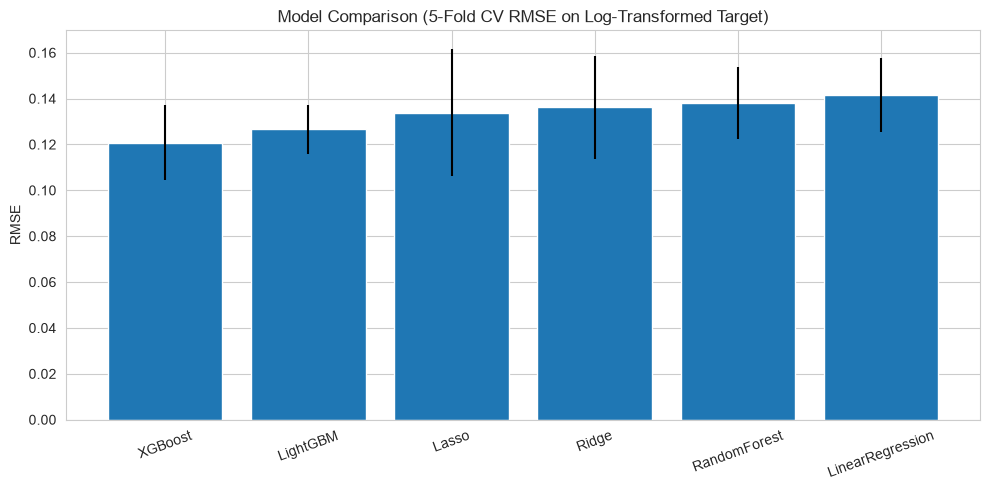

In [ ]:
best_model = comparison.loc[0, "Model"]

colors = [
    "tab:green" if model == best_model else "tab:blue"
    for model in comparison["Model"]
]

plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["Mean RMSE"],
    yerr=comparison["Std RMSE"]
)

plt.xticks(rotation=20)

plt.ylabel("RMSE")

plt.title("Model Comparison (5-Fold CV RMSE on Log-Transformed Target)")

plt.tight_layout()

plt.show()

In [24]:
print(X_train_xgb.shape)
print(X_test_xgb.shape)

(1168, 208)
(292, 208)


In [25]:
print(X_train_xgb.isnull().sum().sum())

0
